In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("./data/churn.csv", index_col=0, parse_dates=["joining_date"])

In [3]:
df.columns

Index(['age', 'gender', 'security_no', 'region_category',
       'membership_category', 'joining_date', 'joined_through_referral',
       'referral_id', 'preferred_offer_types', 'medium_of_operation',
       'internet_option', 'last_visit_time', 'days_since_last_login',
       'avg_time_spent', 'avg_transaction_value', 'avg_frequency_login_days',
       'points_in_wallet', 'used_special_discount',
       'offer_application_preference', 'past_complaint', 'complaint_status',
       'feedback', 'churn_risk_score'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 36992 entries, 0 to 36991
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   age                           36992 non-null  int64         
 1   gender                        36992 non-null  str           
 2   security_no                   36992 non-null  str           
 3   region_category               31564 non-null  str           
 4   membership_category           36992 non-null  str           
 5   joining_date                  36992 non-null  datetime64[us]
 6   joined_through_referral       36992 non-null  str           
 7   referral_id                   36992 non-null  str           
 8   preferred_offer_types         36704 non-null  str           
 9   medium_of_operation           36992 non-null  str           
 10  internet_option               36992 non-null  str           
 11  last_visit_time               36992 non

## Columns with unclear or no-value add to modelling

In [48]:
unclear_value_add_columns = ["security_no", "referral_id"]
df[unclear_value_add_columns].sample(10)

,security_no,referral_id
6071,M4G17F6,CID60779
27371,DQ5O1H1,xxxxxxxx
14400,DRZXDML,xxxxxxxx
6255,GL4FU4N,xxxxxxxx
5319,W8Q2ZNQ,CID25004
22488,YLM03EA,CID13986
32324,23C10U5,CID41937
17448,2THZQAG,xxxxxxxx
10343,HNK1Z55,xxxxxxxx
10826,3SSDYA3,xxxxxxxx


In [63]:
## No overlap between the columns so they don't seem to be related at all
set(df[unclear_value_add_columns[0]].unique()).intersection(set(df[unclear_value_add_columns[1]].unique()))

set()

## Date/Time based columns

In [53]:
date_time_based_columns = ["joining_date", "last_visit_time"]

In [43]:
df_new = df['joining_date'].apply(lambda x: pd.Series([x.year, x.month, x.quarter, x.day, "weekend" if x.weekday() >= 5 else "weekday"]))

# Rename the columns for clarity
df_new.columns = ['year', 'month', 'quarter', 'date', 'weekend']

In [ ]:
def plot_categorical_frequency(column: str, data: pd.DataFrame) -> None:
    counts = data[column].value_counts().sort_index()
    counts.plot(kind='bar')

    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Frequency of values in "{column}" column')
    plt.tight_layout()
    plt.show()

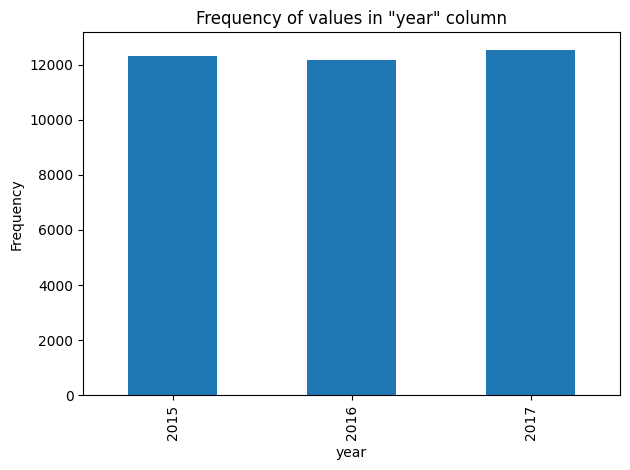

In [ ]:
plot_categorical_frequency('year', df_new)

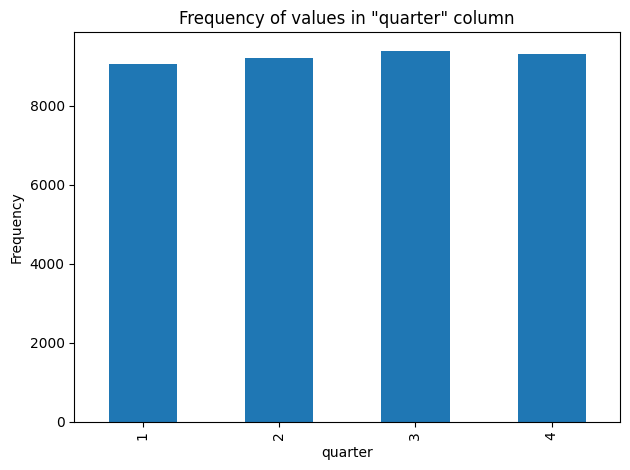

In [ ]:
plot_categorical_frequency('quarter', df_new)

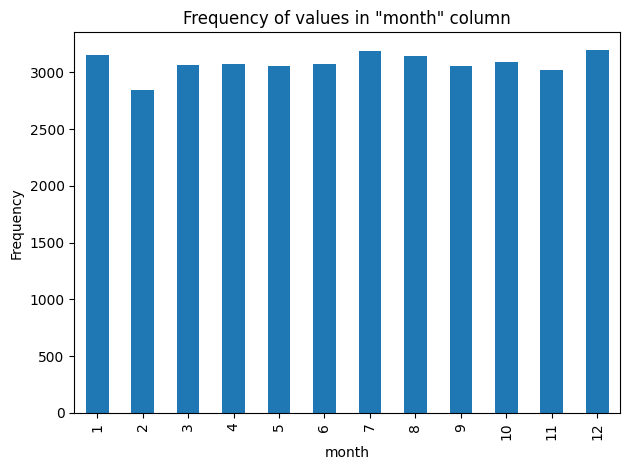

In [ ]:
plot_categorical_frequency('month', df_new)

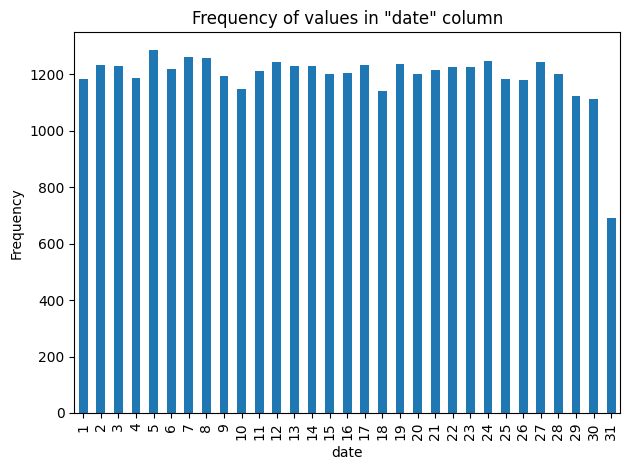

In [ ]:
plot_categorical_frequency('date', df_new)

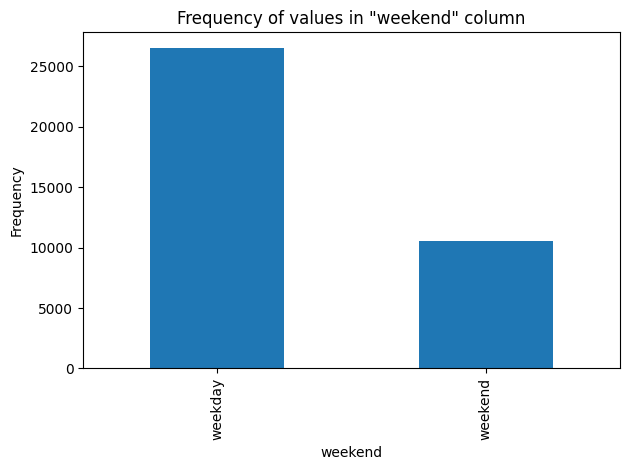

In [ ]:
plot_categorical_frequency('weekend', df_new)

## Mixed datatype column

In [26]:
mixed_numerical = ["avg_frequency_login_days"]
df[mixed_numerical].sample(10)

,avg_frequency_login_days
26099,8.0
14192,27.0
29433,17.0
15114,26.0
25851,15.976715
31659,18.0
27550,-9.402893
13499,18.0
23429,17.0
20872,14.0


In [ ]:
import re

In [8]:
float_pattern = r'^[-+]?\d*\.?\d+$'
bool(re.match(float_pattern, '17'))

True

In [9]:
df["avg_frequency_login_days"] = df["avg_frequency_login_days"].apply(lambda x : float(x) if bool(re.match(float_pattern, x)) else pd.NA)

In [15]:
number_of_na_in_avg_frequency_login_days = sum(df["avg_frequency_login_days"].isna())
print(number_of_na_in_avg_frequency_login_days)
# Replace NA values with mean of the entire column
df["avg_frequency_login_days"] = df["avg_frequency_login_days"].fillna(df["avg_frequency_login_days"].mean())

3522


In [21]:
type(df["avg_frequency_login_days"][0])

float

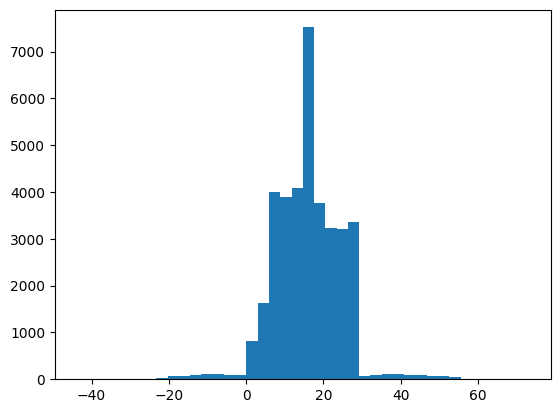

In [29]:
plt.hist(list(df["avg_frequency_login_days"].values), bins=40)
plt.show()

## Numerical Columns

Columns that have a numerical 

In [46]:
numerical_columns = ["days_since_last_login", "avg_time_spent", "avg_transaction_value", "points_in_wallet", "age", "churn_risk_score"]

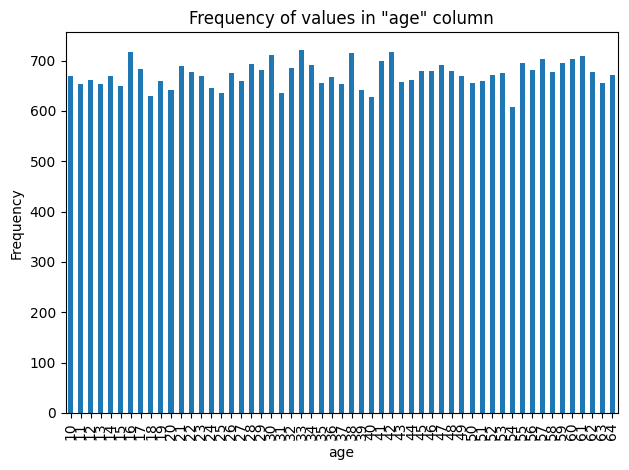

In [ ]:
plot_categorical_frequency("age", df)

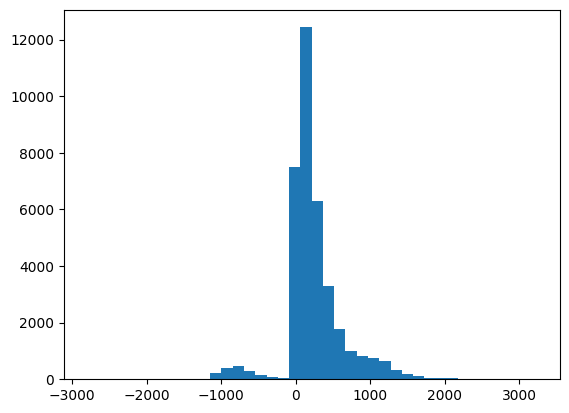

In [28]:
plt.hist(list(df["avg_time_spent"].values), bins=40)
plt.show()

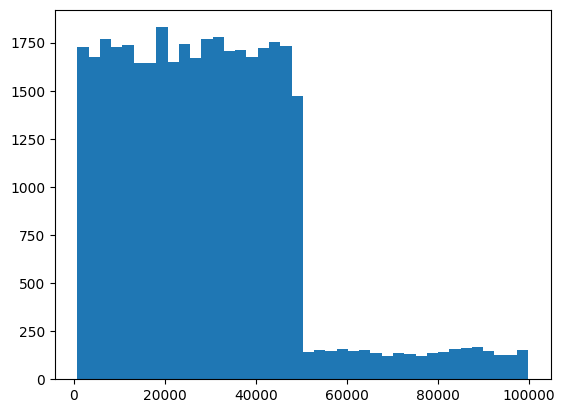

In [30]:
plt.hist(list(df["avg_transaction_value"].values), bins=40)
plt.show()

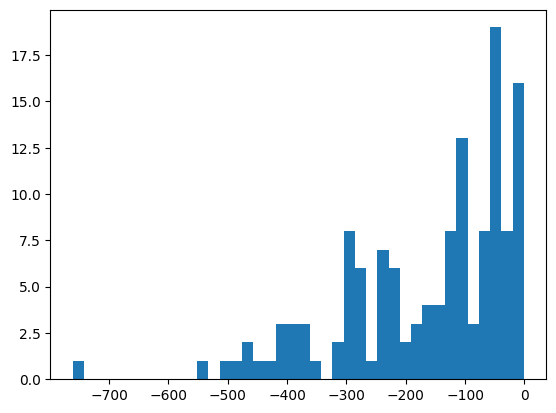

In [70]:
plt.hist(list(df["points_in_wallet"][df["points_in_wallet"] < 0].values), bins=40)
plt.show()

In [ ]:
df["days_since_last_login"][df["days_since_last_login"] < 0].value_counts()

days_since_last_login
-999    1999
Name: count, dtype: int64

In [22]:
df[numerical_columns].describe()

,days_since_last_login,avg_time_spent,avg_transaction_value,points_in_wallet,age,churn_risk_score
count,36992.000000,36992.000000,36992.000000,33549.000000,36992.000000,36992.000000
mean,-41.915576,243.472334,29271.194003,686.882199,37.118161,0.540982
std,228.819900,398.289149,19444.806226,194.063624,15.867412,0.498324
min,-999.000000,-2814.109110,800.460000,-760.661236,10.000000,0.000000
25%,8.000000,60.102500,14177.540000,616.150000,23.000000,0.000000
50%,12.000000,161.765000,27554.485000,697.620000,37.000000,1.000000
75%,16.000000,356.515000,40855.110000,763.950000,51.000000,1.000000
max,26.000000,3235.578521,99914.050000,2069.069761,64.000000,1.000000


### Data cleaning

1. Observed missing and negative values like in `avg_frequency_login_days` - missing were replaced with average, for negative? 
2. Observed negative values in `avg_frequency_login_days`, `avg_time_spent`, `points_in_wallet`

## All other columns

In [62]:
numerical_columns + unclear_value_add_columns + mixed_numerical + date_time_based_columns

['days_since_last_login',
 'avg_time_spent',
 'avg_transaction_value',
 'points_in_wallet',
 'age',
 'churn_risk_score',
 'security_no',
 'referral_id',
 'avg_frequency_login_days',
 'joining_date',
 'last_visit_time']

In [54]:
other_columns = set(df.columns) - set(numerical_columns) - set(unclear_value_add_columns) - set(mixed_numerical) - set(date_time_based_columns)
other_columns

{'complaint_status',
 'feedback',
 'gender',
 'internet_option',
 'joined_through_referral',
 'medium_of_operation',
 'membership_category',
 'offer_application_preference',
 'past_complaint',
 'preferred_offer_types',
 'region_category',
 'used_special_discount'}

### Complaint Columns

/tmp/ipykernel_34424/658726488.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_34424/658726488.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_34424/658726488.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
/tmp/ipykernel_34424/658726488.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assig

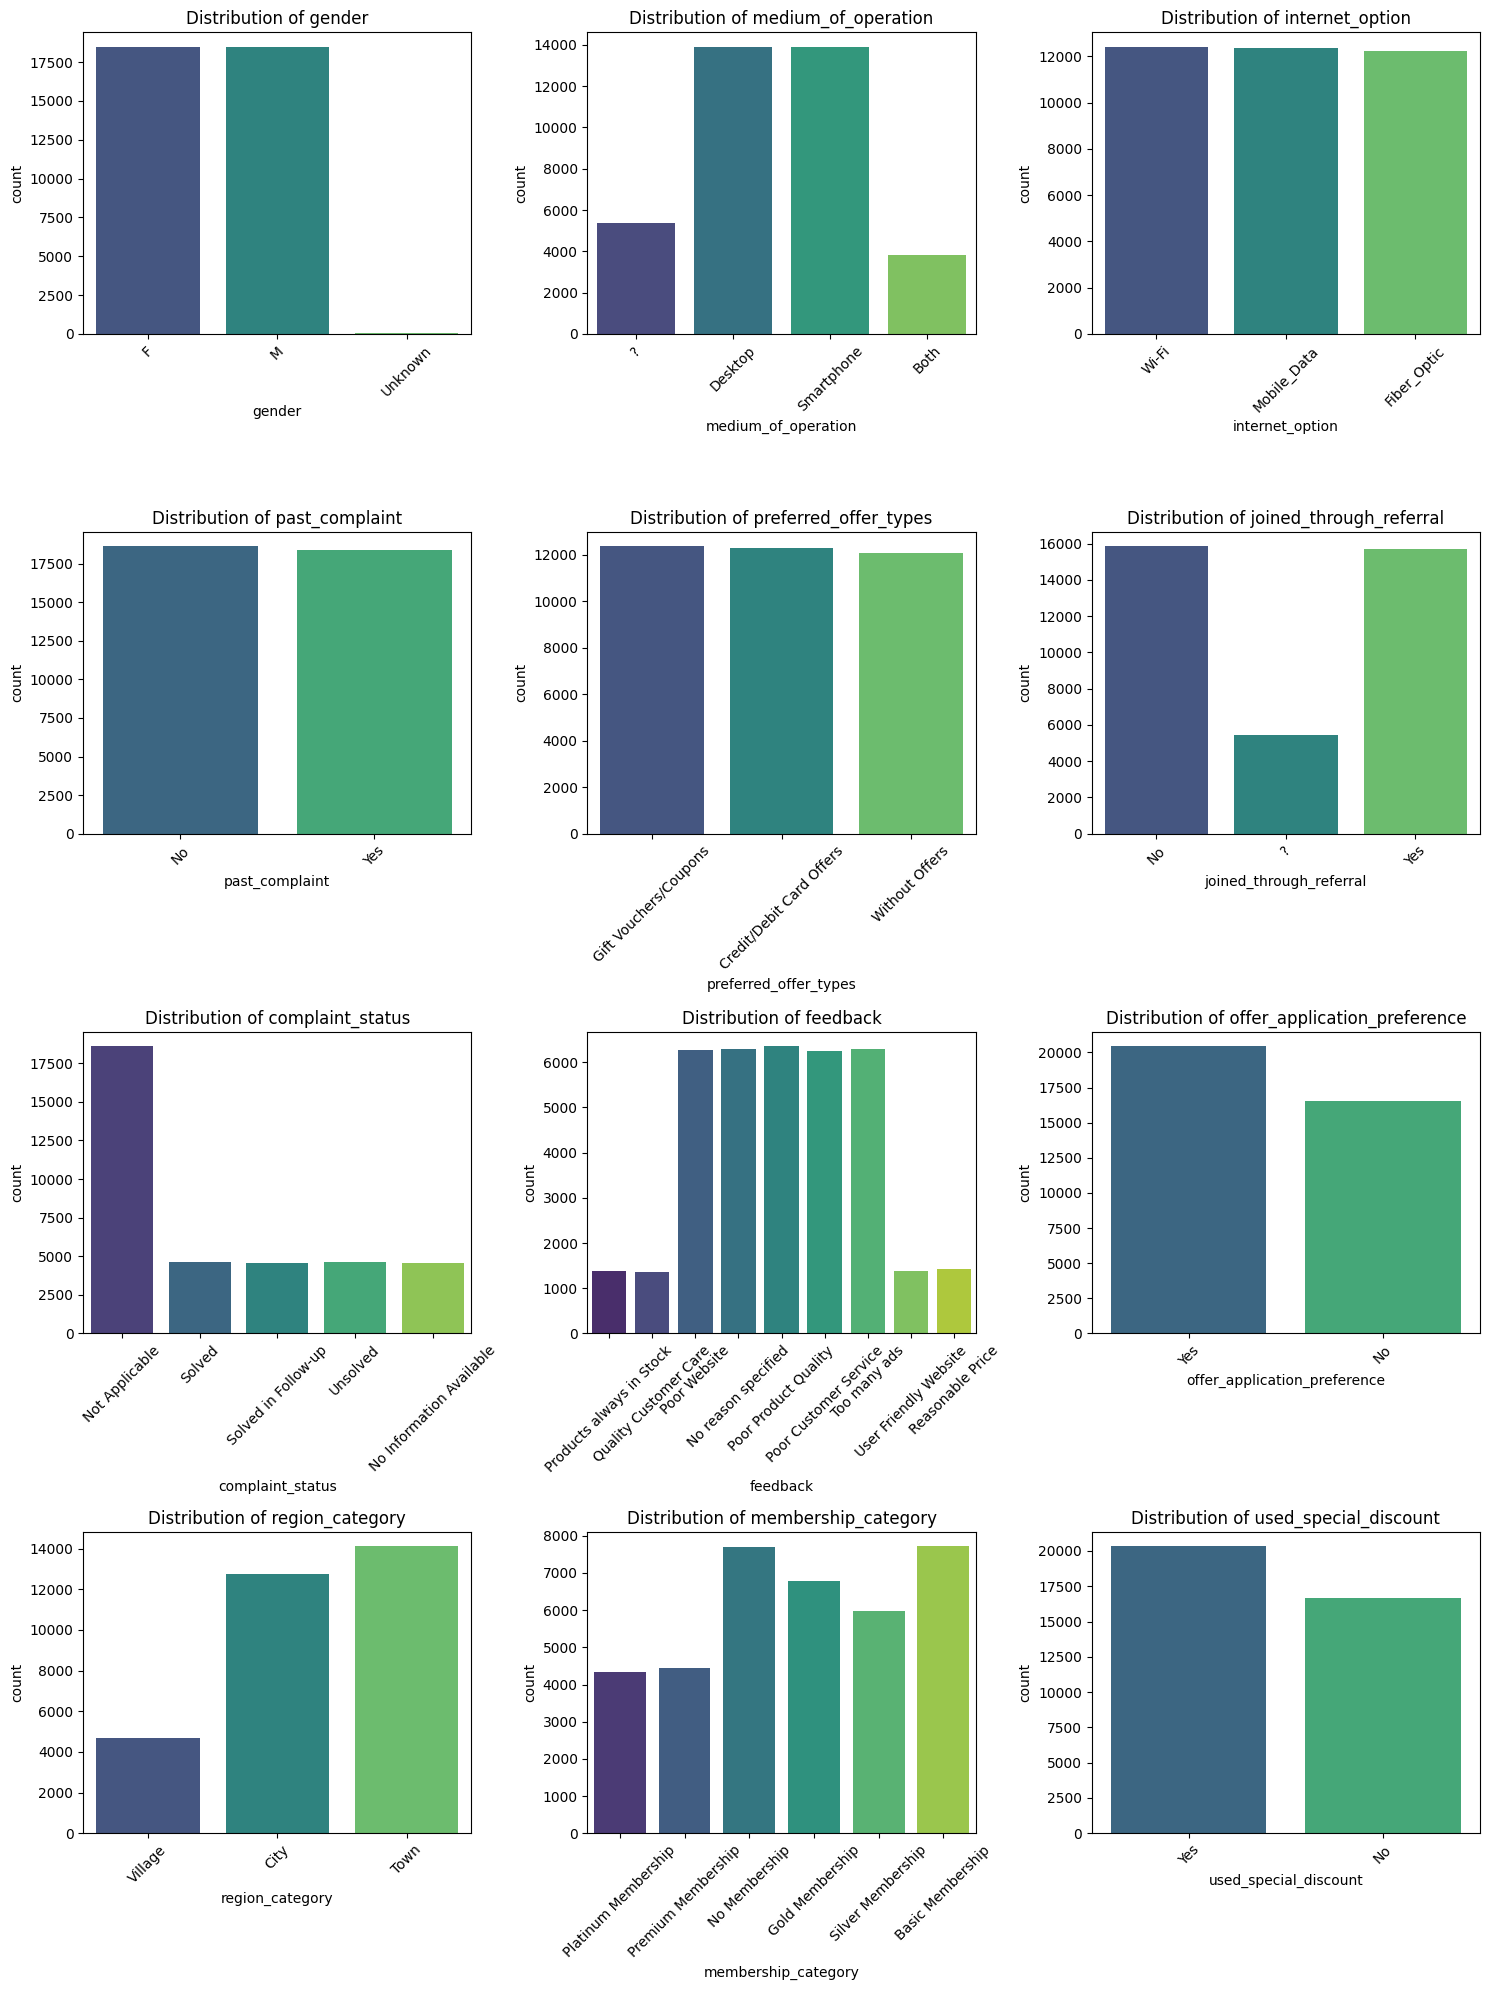

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 3
n_rows = math.ceil(len(other_columns) / n_cols)

# Create the figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten() 

for i, col in enumerate(other_columns):
    sns.countplot(data=df, x=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45) 

# Remove any empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

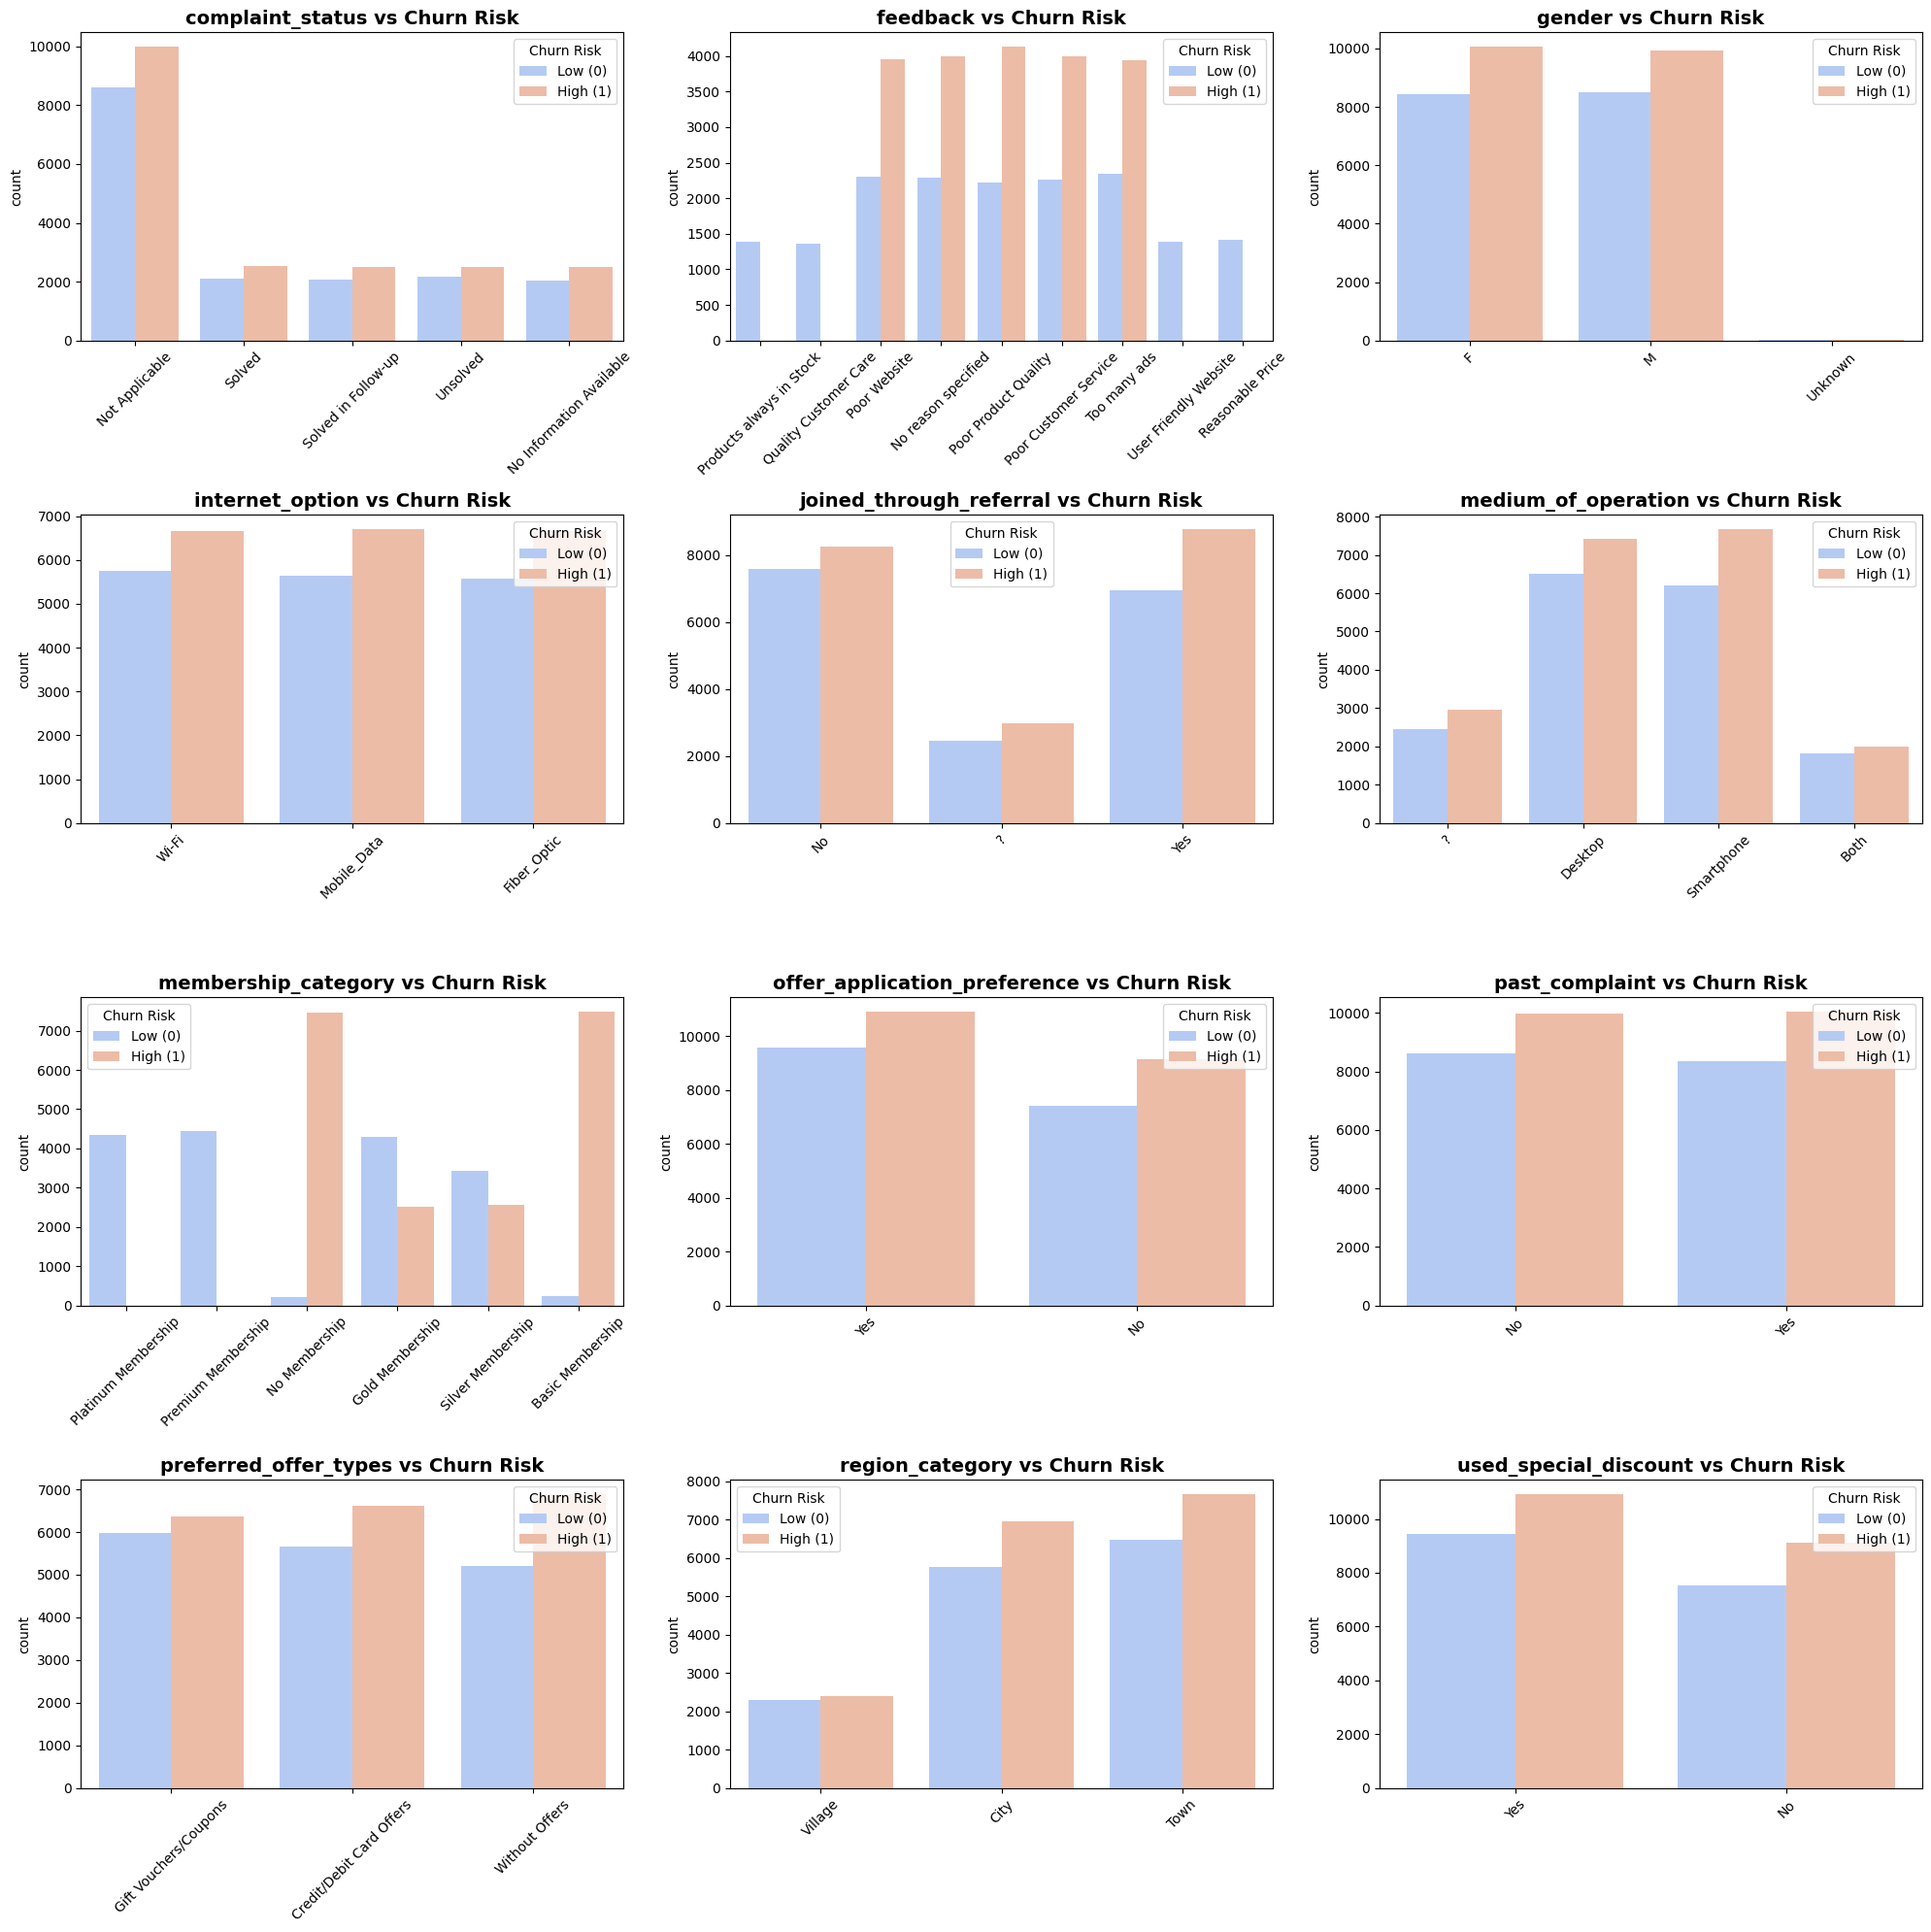

In [60]:
cat_cols = [
    'complaint_status', 'feedback', 'gender', 'internet_option', 
    'joined_through_referral', 'medium_of_operation', 'membership_category', 
    'offer_application_preference', 'past_complaint', 'preferred_offer_types', 
    'region_category', 'used_special_discount'
]

target = 'churn_risk_score'

# Define grid
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # Plotting count with target hue
    sns.countplot(data=df, x=col, hue=target, ax=axes[i], palette='coolwarm')
    
    axes[i].set_title(f'{col} vs Churn Risk', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title='Churn Risk', labels=['Low (0)', 'High (1)'])

# Clean up empty slots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

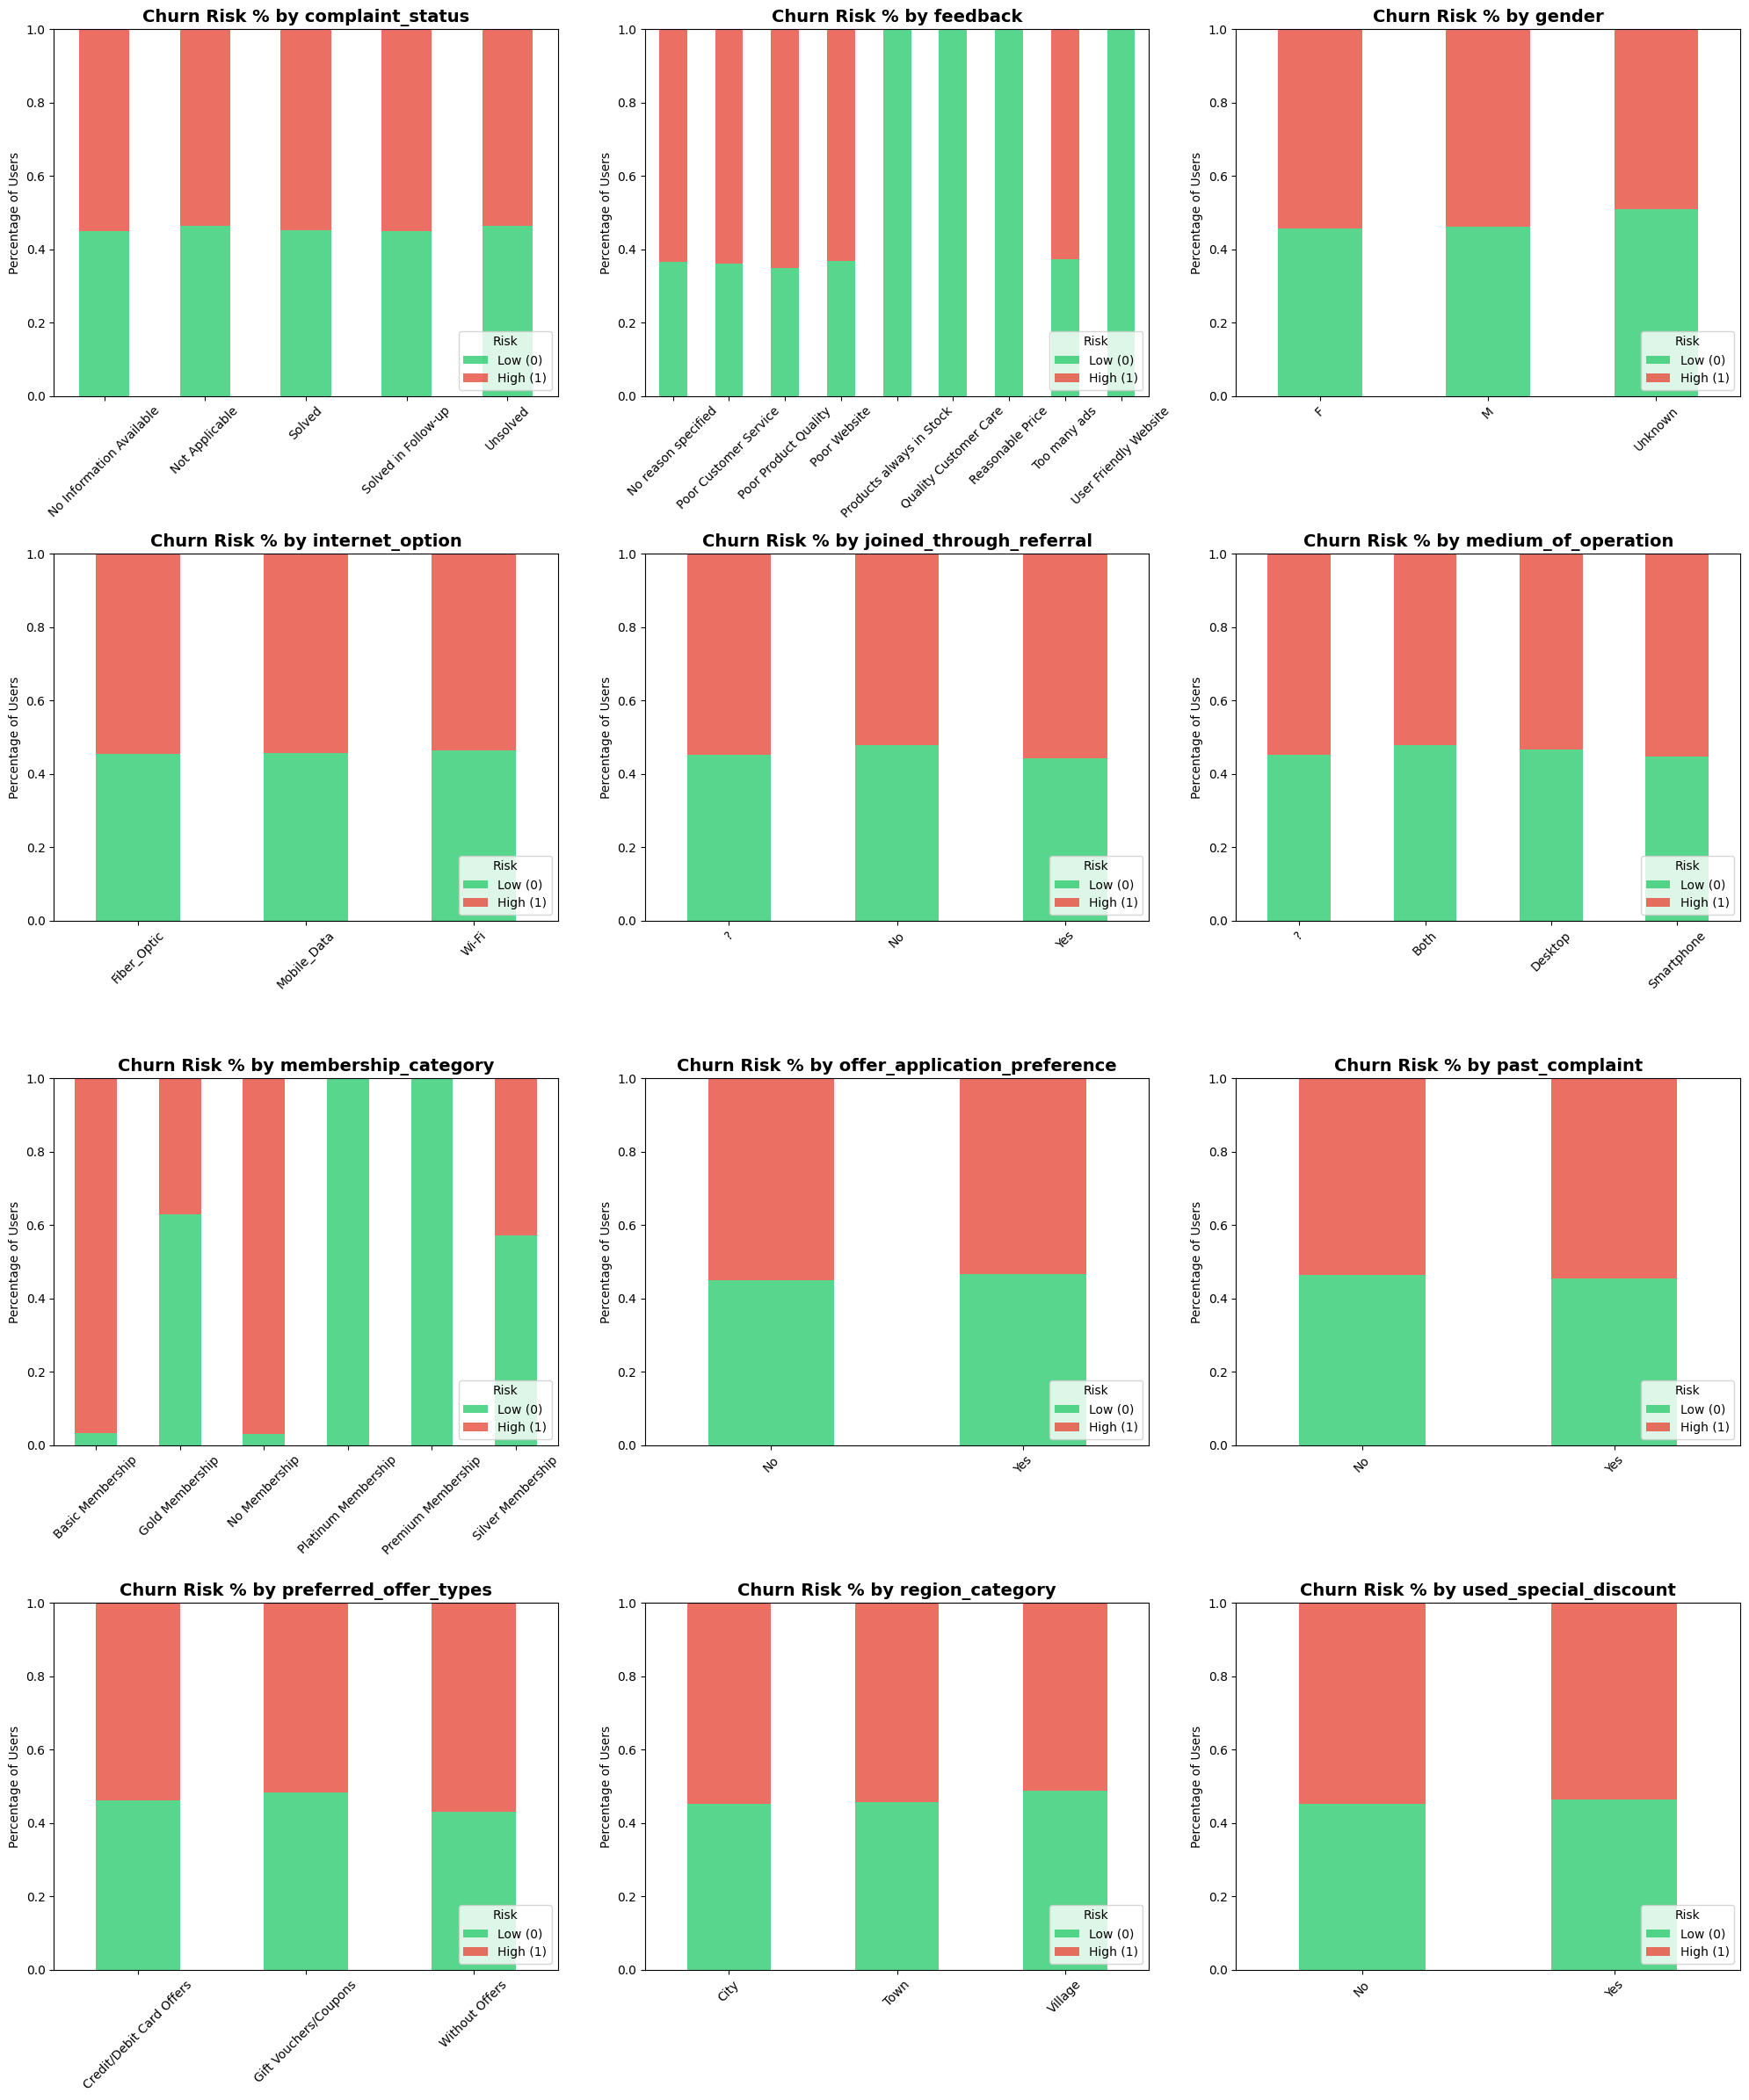

In [63]:
cat_cols = [
    'complaint_status', 'feedback', 'gender', 'internet_option', 
    'joined_through_referral', 'medium_of_operation', 'membership_category', 
    'offer_application_preference', 'past_complaint', 'preferred_offer_types', 
    'region_category', 'used_special_discount'
]

target = 'churn_risk_score'

# Grid setup
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 6))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    # 1. Create a cross-tabulation and normalize by row (index)
    # This turns counts into percentages that sum to 1.0 (100%)
    cross_tab = pd.crosstab(df[col], df[target], normalize='index')
    
    # 2. Plot as a stacked bar chart
    cross_tab.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'], alpha=0.8)
    
    axes[i].set_title(f'Churn Risk % by {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Percentage of Users')
    axes[i].set_xlabel('')
    axes[i].set_ylim(0, 1) # Force 0 to 100% scale
    axes[i].legend(title='Risk', labels=['Low (0)', 'High (1)'], loc='lower right')
    axes[i].tick_params(axis='x', rotation=45)

# Clean up empty slots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

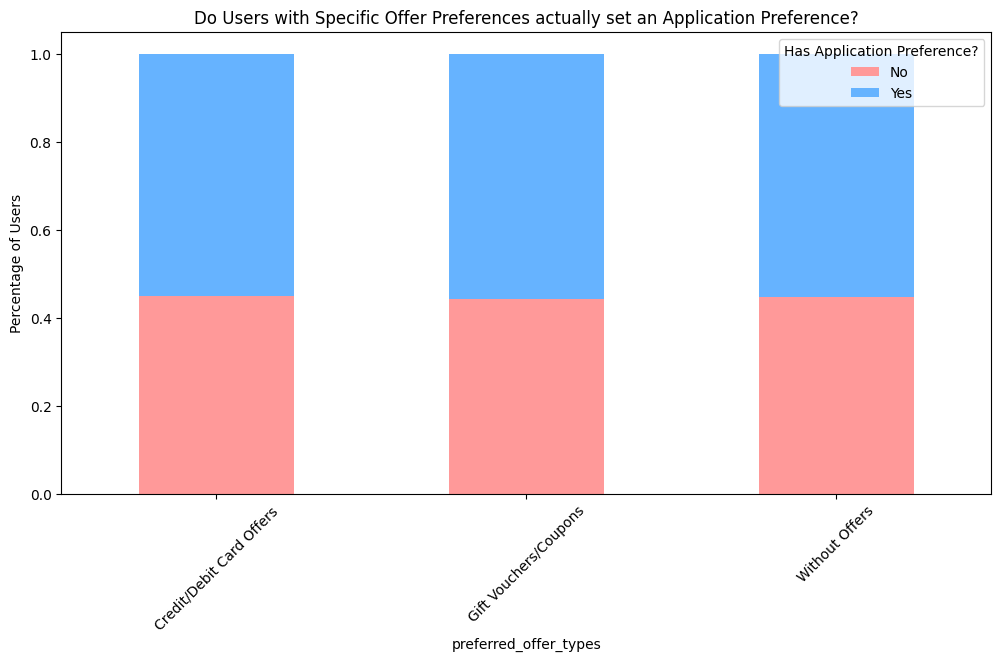

In [56]:
# Cross-tabulate and plot
plt.figure(figsize=(12, 6))
ct = pd.crosstab(df['preferred_offer_types'], df['offer_application_preference'], normalize='index')

ct.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'], ax=plt.gca())
plt.title('Do Users with Specific Offer Preferences actually set an Application Preference?')
plt.ylabel('Percentage of Users')
plt.legend(title='Has Application Preference?', loc='upper right')
plt.xticks(rotation=45)
plt.show()

### Aspects to think about

Membership tiers are clear indicators of churn risk, and also the feedback, negative feedback being a good indicator of churn. I am struggling to understand these columns from a timeline perspective though. With the churn_risk_score being 0 or 1, is feedback collected after churn has occurred? Also what does risk being 0 or 1 mean? Is it recording an event?

Bit of analysis for that:

In [ ]:
# Check how many 'Risk 0' people actually give negative feedback
mismatch = df[(df['churn_risk_score'] == 0) & (df['feedback'].str.contains('Poor|No|Too', na=False))]
print(f"Users with bad feedback who haven't churned: {len(mismatch)}")

Users with bad feedback who haven't churned: 20012


This leads us to believe that the feedback can be used in the modelling because it isn't something that is collected at the moment of churn. Possibly something collected while the user is still active.